## Phase 7 - EXPLAINABLE AI

In [34]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)
print(sys.version)

/Users/aximsoft/tfenv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]


In [79]:
import os
os.makedirs("images", exist_ok=True)
print("Folder created successfully!")

Folder created successfully!


In [103]:
final_model_resnet= load_model("models2/resnet_SGD.keras")
final_model_resnet.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,166,743 (96.00 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,052,688 (4.02 MB)

In [104]:
class_names = ["akiec","bcc","bkl","df","mel","nv","vasc"]

In [105]:
img_path = "dataset/HAM10000_images_part_2/ISIC_0029306.jpg"

In [106]:
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

In [107]:
prediction = final_model_resnet.predict(img_array)
predicted_class = np.argmax(prediction)
print("Predicted Disease :", class_names[predicted_class])
print("Confidence :", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Disease : nv
Confidence : 0.91326404


In [108]:
for layer in final_model_resnet.layers:
    print(layer.name, layer.__class__.__name__)

input_layer_4 InputLayer
conv1_pad ZeroPadding2D
conv1_conv Conv2D
conv1_bn BatchNormalization
conv1_relu Activation
pool1_pad ZeroPadding2D
pool1_pool MaxPooling2D
conv2_block1_1_conv Conv2D
conv2_block1_1_bn BatchNormalization
conv2_block1_1_relu Activation
conv2_block1_2_conv Conv2D
conv2_block1_2_bn BatchNormalization
conv2_block1_2_relu Activation
conv2_block1_0_conv Conv2D
conv2_block1_3_conv Conv2D
conv2_block1_0_bn BatchNormalization
conv2_block1_3_bn BatchNormalization
conv2_block1_add Add
conv2_block1_out Activation
conv2_block2_1_conv Conv2D
conv2_block2_1_bn BatchNormalization
conv2_block2_1_relu Activation
conv2_block2_2_conv Conv2D
conv2_block2_2_bn BatchNormalization
conv2_block2_2_relu Activation
conv2_block2_3_conv Conv2D
conv2_block2_3_bn BatchNormalization
conv2_block2_add Add
conv2_block2_out Activation
conv2_block3_1_conv Conv2D
conv2_block3_1_bn BatchNormalization
conv2_block3_1_relu Activation
conv2_block3_2_conv Conv2D
conv2_block3_2_bn BatchNormalization
conv2_

In [109]:
#heatmap
last_conv_layer = "conv5_block3_3_conv"

grad_model = tf.keras.models.Model(
    inputs=final_model_resnet.input,
    outputs=[
        final_model_resnet.get_layer(last_conv_layer).output,
        final_model_resnet.output
    ]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]
    
grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap,0)
heatmap /= tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

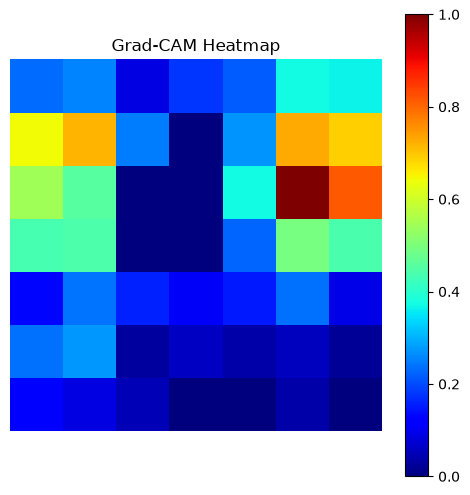

In [110]:
#gradcam
plt.figure(figsize=(6,6))
plt.imshow(heatmap,cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis("off")
plt.savefig("images/GRAD-CAM.png", dpi=300, bbox_inches="tight")
plt.show()

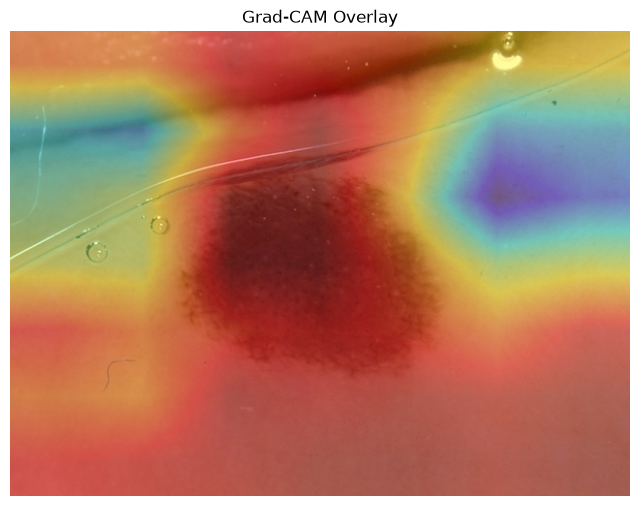

In [111]:
# overlay heatmap on original img
original = cv2.imread(img_path)
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
heatmap = cv2.resize(
    heatmap,
    (original.shape[1],original.shape[0])
)
heatmap = np.uint8(255*heatmap)
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)
superimposed = cv2.addWeighted(
    original,
    0.6,
    heatmap,
    0.4,
    0
)
plt.figure(figsize=(8,8))
plt.imshow(superimposed)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.savefig("images/GRADCAM_OVERLAY.png", dpi=300, bbox_inches="tight")
plt.show()

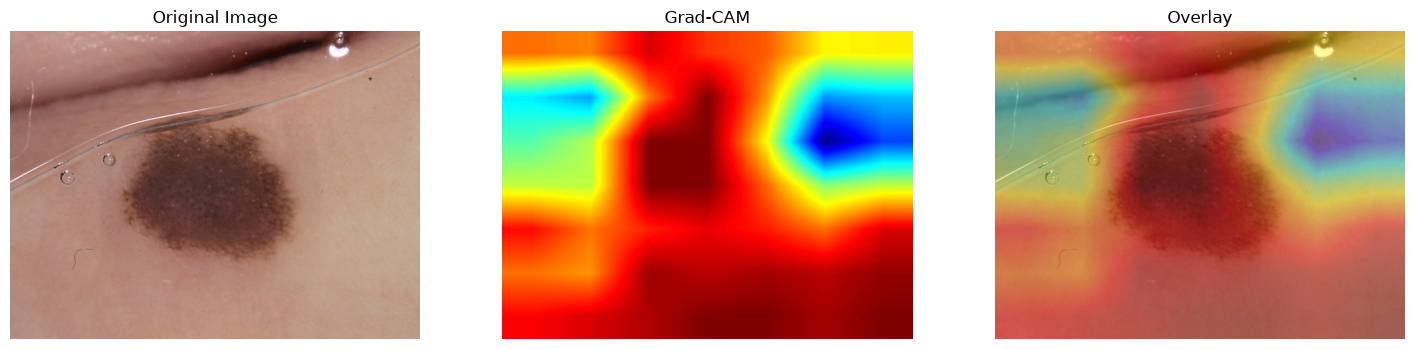

In [112]:
#all images together
fig,ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(original)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(heatmap,cmap="jet")
ax[1].set_title("Grad-CAM")
ax[1].axis("off")

ax[2].imshow(superimposed)
ax[2].set_title("Overlay")
ax[2].axis("off")
plt.savefig("images/ALL_TOGETHER.png", dpi=300, bbox_inches="tight")
plt.show()